In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# For fetching data
from pandas_datareader import data as pdr
import yfinance as yf

In [2]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("CASE STUDY 1: Macroeconomic VAR Analysis")
print("=" * 70)

CASE STUDY 1: Macroeconomic VAR Analysis


In [6]:
from pandas_datareader import data as web 
# Define date range
start_date = '1960-01-01'
end_date = '2024-12-31'

# Fetch data from FRED
# GDP (Quarterly, Billions of Dollars)
gdp = web.DataReader('GDP', 'fred', start_date, end_date)

# Consumer Price Index (Monthly, converted to quarterly)
cpi = web.DataReader('CPIAUCSL', 'fred', start_date, end_date)

# Unemployment Rate (Monthly, converted to quarterly)
unemployment = web.DataReader('UNRATE', 'fred', start_date, end_date)

# Federal Funds Rate (Monthly, converted to quarterly)
interest_rate = web.DataReader('FEDFUNDS', 'fred', start_date, end_date)

print("✓ Data successfully fetched from FRED")

✓ Data successfully fetched from FRED


In [7]:
gdp

,GDP
DATE,
1960-01-01,542.648
1960-04-01,541.080
1960-07-01,545.604
1960-10-01,540.197
1961-01-01,545.018
...,...
2023-10-01,28424.722
2024-01-01,28708.161
2024-04-01,29147.044


In [10]:
interest_rate

,FEDFUNDS
DATE,
1960-01-01,3.99
1960-02-01,3.97
1960-03-01,3.84
1960-04-01,3.92
1960-05-01,3.85
...,...
2024-08-01,5.33
2024-09-01,5.13
2024-10-01,4.83


In [11]:
cpi.head()

,CPIAUCSL
DATE,
1960-01-01,29.37
1960-02-01,29.41
1960-03-01,29.41
1960-04-01,29.54
1960-05-01,29.57


In [12]:
cpi = cpi.resample('Q').mean()
unemployment = unemployment.resample('Q').mean()
interest_rate = interest_rate.resample('Q').mean()

In [13]:
cpi.head()

,CPIAUCSL
DATE,
1960-03-31,29.396667
1960-06-30,29.573333
1960-09-30,29.590000
1960-12-31,29.780000
1961-03-31,29.840000


In [14]:
gdp.head()

,GDP
DATE,
1960-01-01,542.648
1960-04-01,541.080
1960-07-01,545.604
1960-10-01,540.197
1961-01-01,545.018


In [15]:
gdp = gdp.resample('Q').last()

In [16]:
gdp.head()

,GDP
DATE,
1960-03-31,542.648
1960-06-30,541.080
1960-09-30,545.604
1960-12-31,540.197
1961-03-31,545.018


In [17]:
data = pd.DataFrame({
    'GDP': gdp['GDP'].values,
    'CPI': cpi.iloc[:, 0].values,
    'UNEMPLOYMENT': unemployment.iloc[:, 0].values,
    'INTEREST_RATE': interest_rate.iloc[:, 0].values
}, index=gdp.index)

In [18]:
data

,GDP,CPI,UNEMPLOYMENT,INTEREST_RATE
DATE,,,,
1960-03-31,542.648,29.396667,5.133333,3.933333
1960-06-30,541.080,29.573333,5.233333,3.696667
1960-09-30,545.604,29.590000,5.533333,2.936667
1960-12-31,540.197,29.780000,6.266667,2.296667
1961-03-31,545.018,29.840000,6.800000,2.003333
...,...,...,...,...
2023-12-31,28424.722,308.158333,3.800000,5.330000
2024-03-31,28708.161,310.974333,3.833333,5.330000
2024-06-30,29147.044,313.095667,4.000000,5.330000


In [19]:
# Remove missing values
data = data.dropna()

# Calculate growth rates
data['GDP_GROWTH'] = data['GDP'].pct_change() * 100  # Percentage growth
data['INFLATION'] = data['CPI'].pct_change() * 100   # Percentage change

# Keep relevant columns
df = data[['GDP_GROWTH', 'INFLATION', 'UNEMPLOYMENT', 'INTEREST_RATE']].dropna()

print(f"✓ Dataset shape: {df.shape}")
print(f"✓ Date range: {df.index[0]} to {df.index[-1]}")
print(f"✓ Total observations: {len(df)}")

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe().round(2))

✓ Dataset shape: (259, 4)
✓ Date range: 1960-06-30 00:00:00 to 2024-12-31 00:00:00
✓ Total observations: 259

Summary Statistics:
       GDP_GROWTH  INFLATION  UNEMPLOYMENT  INTEREST_RATE
count      259.00     259.00        259.00         259.00
mean         1.57       0.92          5.89           4.80
std          1.21       0.76          1.69           3.63
min         -8.24      -2.29          3.40           0.06
25%          1.05       0.51          4.67           1.94
50%          1.46       0.80          5.63           4.75
75%          2.03       1.14          6.95           6.52
max          8.75       3.95         13.00          17.78


In [20]:
df

,GDP_GROWTH,INFLATION,UNEMPLOYMENT,INTEREST_RATE
DATE,,,,
1960-06-30,-0.288953,0.600975,5.233333,3.696667
1960-09-30,0.836106,0.056357,5.533333,2.936667
1960-12-31,-0.991012,0.642109,6.266667,2.296667
1961-03-31,0.892452,0.201478,6.800000,2.003333
1961-06-30,1.931496,-0.033512,7.000000,1.733333
...,...,...,...,...
2023-12-31,1.246226,0.691408,3.800000,5.330000
2024-03-31,0.997157,0.913816,3.833333,5.330000
2024-06-30,1.528774,0.682157,4.000000,5.330000



[Step 3] Exploratory Data Analysis...


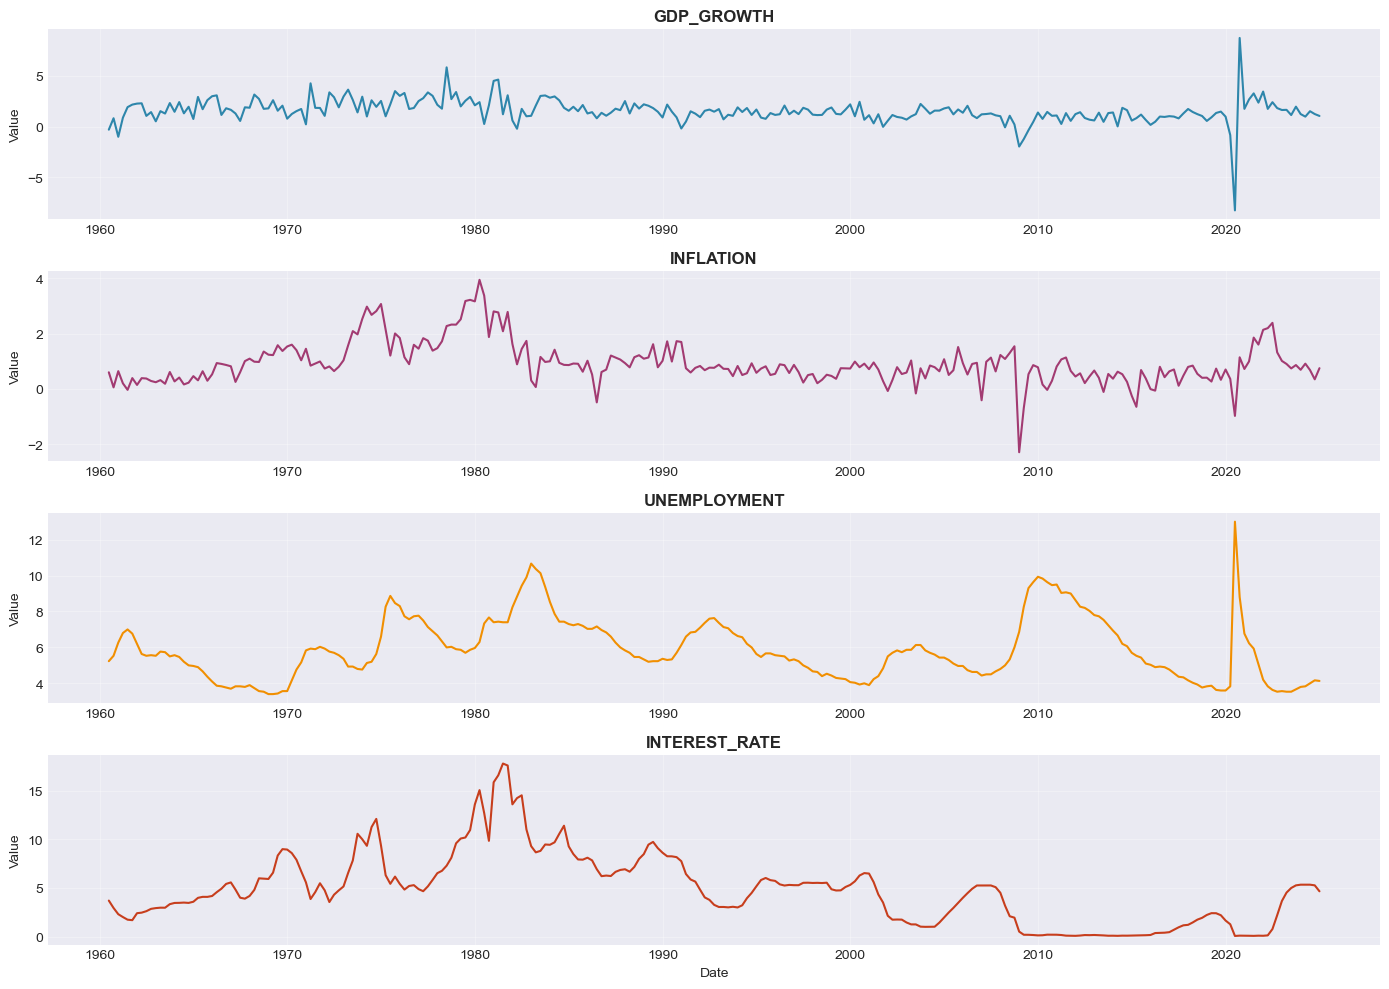

In [21]:
print("\n[Step 3] Exploratory Data Analysis...")

# Plot 1: Time series plots
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
variables = df.columns
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (var, color) in enumerate(zip(variables, colors)):
    axes[i].plot(df.index, df[var], color=color, linewidth=1.5)
    axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

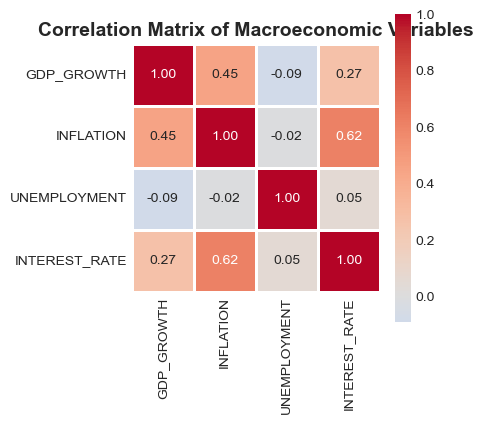

In [24]:
plt.figure(figsize=(4,4))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Macroeconomic Variables', fontsize=14, fontweight='bold')
plt.show()


<Figure size 1200x1000 with 0 Axes>

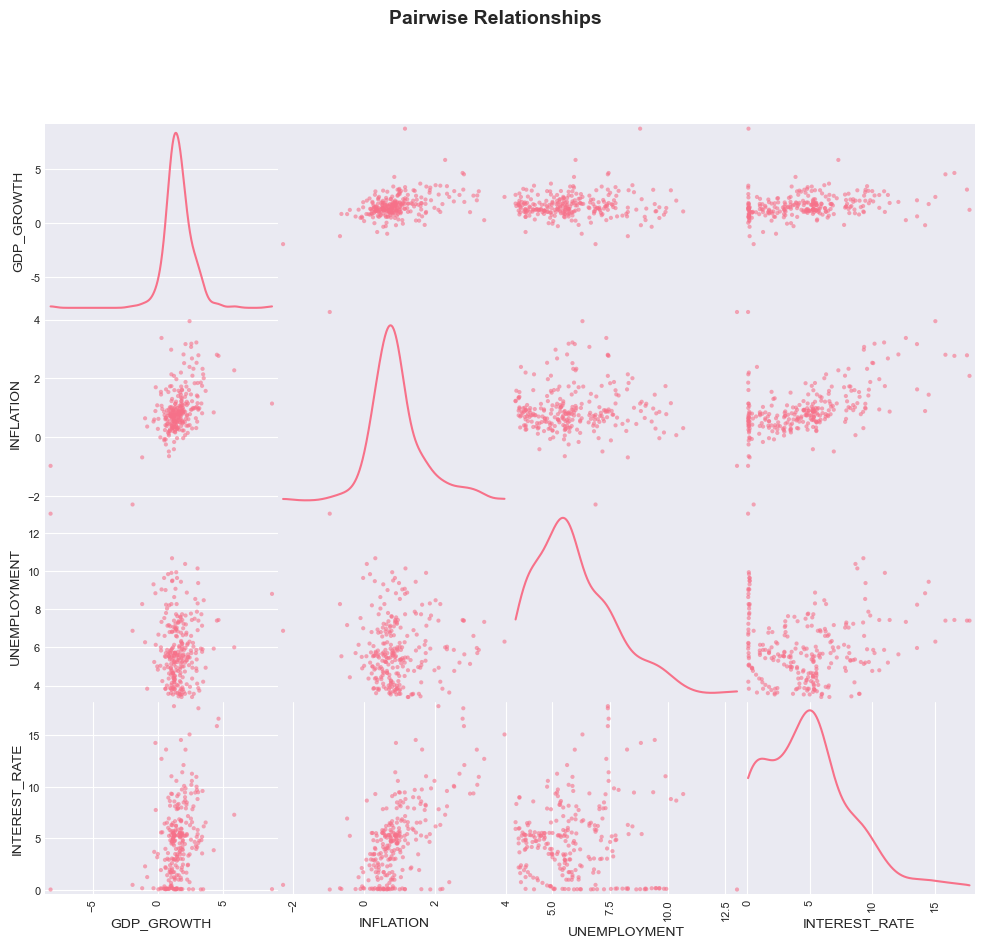


Key Observations from EDA:
  • GDP Growth - Mean: 1.57%, Std: 1.21%
  • Inflation - Mean: 0.92%, Std: 0.76%
  • Unemployment - Mean: 5.89%, Std: 1.69%
  • Interest Rate - Mean: 4.80%, Std: 3.63%


In [25]:
fig = plt.figure(figsize=(12, 10))
pd.plotting.scatter_matrix(df, alpha=0.6, figsize=(12, 10), diagonal='kde')
plt.suptitle('Pairwise Relationships', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\nKey Observations from EDA:")
print(f"  • GDP Growth - Mean: {df['GDP_GROWTH'].mean():.2f}%, Std: {df['GDP_GROWTH'].std():.2f}%")
print(f"  • Inflation - Mean: {df['INFLATION'].mean():.2f}%, Std: {df['INFLATION'].std():.2f}%")
print(f"  • Unemployment - Mean: {df['UNEMPLOYMENT'].mean():.2f}%, Std: {df['UNEMPLOYMENT'].std():.2f}%")
print(f"  • Interest Rate - Mean: {df['INTEREST_RATE'].mean():.2f}%, Std: {df['INTEREST_RATE'].std():.2f}%")


In [26]:
print("\n[Step 4] Testing for Stationarity (Augmented Dickey-Fuller Test)...")

def adf_test(series, name=''):
    """Perform Augmented Dickey-Fuller test"""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n  {name}:')
    print(f'    ADF Statistic: {result[0]:.4f}')
    print(f'    p-value: {result[1]:.4f}')
    print(f'    Critical Values:')
    for key, value in result[4].items():
        print(f'      {key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print(f'    ✓ Stationary (reject null hypothesis)')
        return True
    else:
        print(f'    ✗ Non-stationary (fail to reject null hypothesis)')
        return False

stationarity_results = {}
for col in df.columns:
    stationarity_results[col] = adf_test(df[col], name=col)


[Step 4] Testing for Stationarity (Augmented Dickey-Fuller Test)...

  GDP_GROWTH:
    ADF Statistic: -5.6764
    p-value: 0.0000
    Critical Values:
      1%: -3.456
      5%: -2.873
      10%: -2.573
    ✓ Stationary (reject null hypothesis)

  INFLATION:
    ADF Statistic: -3.1513
    p-value: 0.0230
    Critical Values:
      1%: -3.456
      5%: -2.873
      10%: -2.573
    ✓ Stationary (reject null hypothesis)

  UNEMPLOYMENT:
    ADF Statistic: -3.4066
    p-value: 0.0107
    Critical Values:
      1%: -3.456
      5%: -2.873
      10%: -2.573
    ✓ Stationary (reject null hypothesis)

  INTEREST_RATE:
    ADF Statistic: -2.1376
    p-value: 0.2297
    Critical Values:
      1%: -3.457
      5%: -2.873
      10%: -2.573
    ✗ Non-stationary (fail to reject null hypothesis)


In [27]:
stationarity_results

{'GDP_GROWTH': True,
 'INFLATION': True,
 'UNEMPLOYMENT': True,
 'INTEREST_RATE': False}

In [28]:
df_stationary = df.copy()
for col in df.columns:
    if not stationarity_results[col]:
        print(f"\n  Differencing {col}...")
        df_stationary[col] = df[col].diff()
        print(f"  Re-testing {col} after differencing:")
        adf_test(df_stationary[col].dropna(), name=f'{col} (differenced)')

# Remove NaN values created by differencing
df_stationary = df_stationary.dropna()

print(f"\n✓ Final dataset for modeling: {df_stationary.shape}")


  Differencing INTEREST_RATE...
  Re-testing INTEREST_RATE after differencing:

  INTEREST_RATE (differenced):
    ADF Statistic: -7.0164
    p-value: 0.0000
    Critical Values:
      1%: -3.457
      5%: -2.873
      10%: -2.573
    ✓ Stationary (reject null hypothesis)

✓ Final dataset for modeling: (258, 4)



[Step 3] Exploratory Data Analysis...


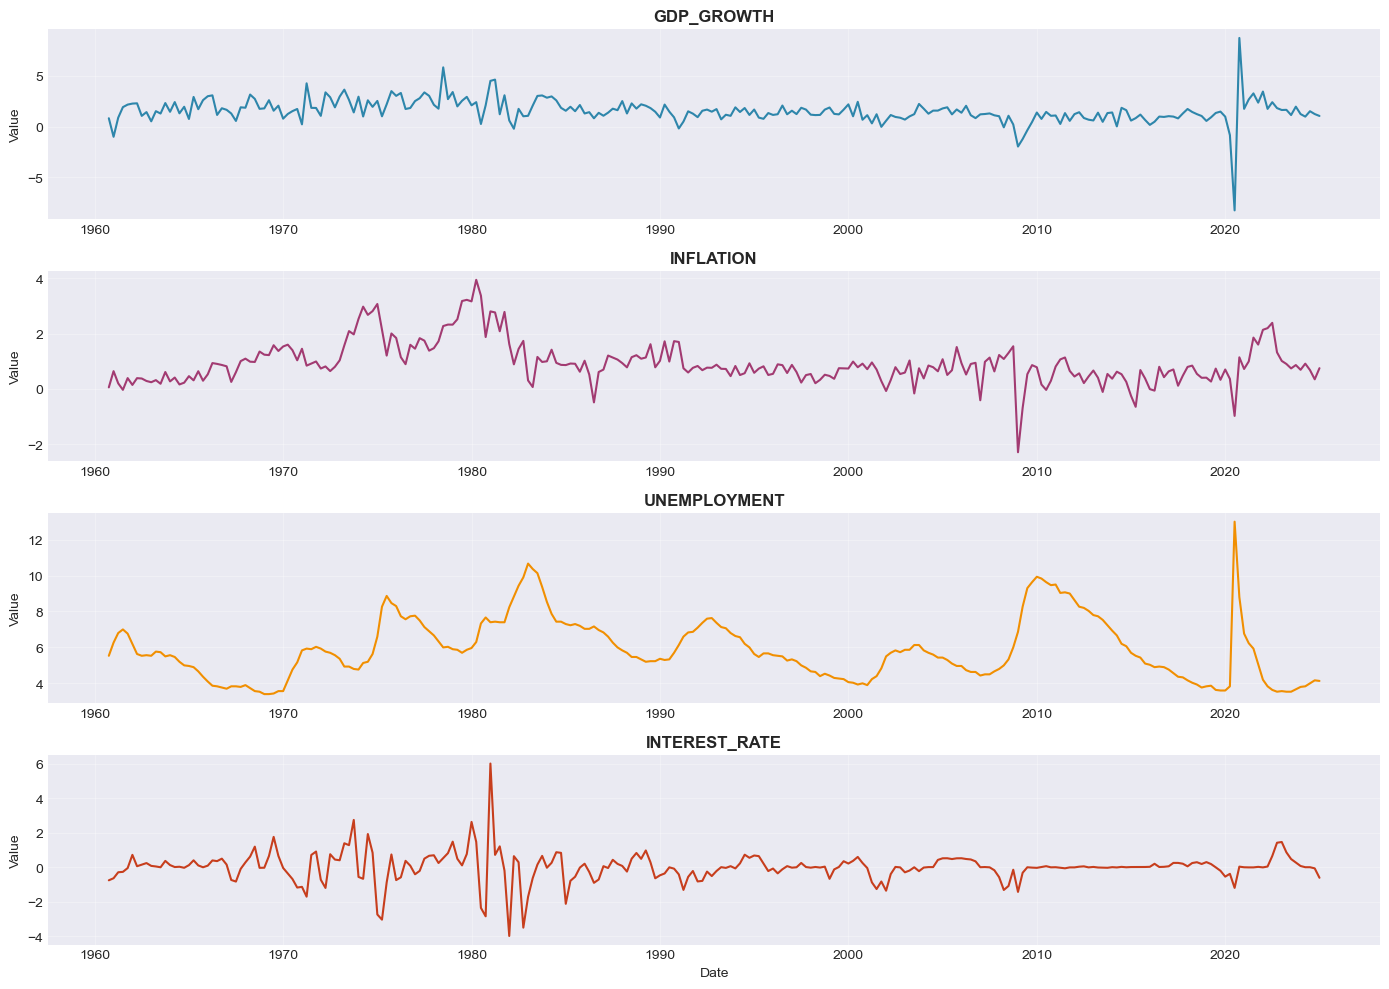

In [29]:
print("\n[Step 3] Exploratory Data Analysis...")

# Plot 1: Time series plots
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
variables = df.columns
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, (var, color) in enumerate(zip(variables, colors)):
    axes[i].plot(df_stationary.index, df_stationary[var], color=color, linewidth=1.5)
    axes[i].set_title(f'{var}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [30]:
print("\n[Step 5] VAR Model - Selecting Optimal Lag Order...")

model = VAR(df_stationary)


[Step 5] VAR Model - Selecting Optimal Lag Order...


In [32]:
lag_order_results = model.select_order(maxlags=12)

In [33]:
lag_order_results.summary()

,AIC,BIC,FPE,HQIC
0,0.3586,0.4156,1.431,0.3815
1,-3.133,-2.848,0.04361,-3.018
2,-3.444,-2.931*,0.03194,-3.237*
3,-3.477*,-2.736,0.03093*,-3.178
4,-3.453,-2.484,0.03168,-3.063
5,-3.475,-2.278,0.03102,-2.993
6,-3.436,-2.011,0.03229,-2.862
7,-3.420,-1.767,0.03286,-2.754
8,-3.431,-1.550,0.03257,-2.674
9,-3.388,-1.279,0.03410,-2.539


In [34]:
print("\n[Step 5] VAR Model - Selecting Optimal Lag Order...")

model = VAR(df_stationary)
lag_order_results = model.select_order(maxlags=12)

print("\nLag Order Selection Criteria:")
print(lag_order_results.summary())

# Select based on AIC
optimal_lag = lag_order_results.aic
print(f"\n✓ Optimal lag order (AIC): {optimal_lag}")


[Step 5] VAR Model - Selecting Optimal Lag Order...

Lag Order Selection Criteria:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.3586      0.4156       1.431      0.3815
1       -3.133      -2.848     0.04361      -3.018
2       -3.444     -2.931*     0.03194     -3.237*
3      -3.477*      -2.736    0.03093*      -3.178
4       -3.453      -2.484     0.03168      -3.063
5       -3.475      -2.278     0.03102      -2.993
6       -3.436      -2.011     0.03229      -2.862
7       -3.420      -1.767     0.03286      -2.754
8       -3.431      -1.550     0.03257      -2.674
9       -3.388      -1.279     0.03410      -2.539
10      -3.404      -1.067     0.03366      -2.463
11      -3.364     -0.7989     0.03518      -2.331
12      -3.304     -0.5112     0.03753      -2.180
--------------------------------------------------

✓ Optimal lag order (AIC): 3


In [35]:
print(f"\n[Step 6] Fitting VAR({optimal_lag}) Model...")

var_model = model.fit(optimal_lag)
print("\n" + "="*70)
print(var_model.summary())
print("="*70)


[Step 6] Fitting VAR(3) Model...

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 26, Oct, 2025
Time:                     12:18:41
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -2.86308
Nobs:                     255.000    HQIC:                  -3.29474
Log likelihood:          -938.202    FPE:                  0.0277405
AIC:                     -3.58522    Det(Omega_mle):       0.0227372
--------------------------------------------------------------------
Results for equation GDP_GROWTH
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -0.449149         0.292401           -1.536           0.125
L1.GDP_GROWTH            0.492152         0.099242            4.959           0.000
L1.INFLA


[Step 7] Model Diagnostics...

1. Serial Correlation Test (Durbin-Watson):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         170.1          137.7   0.000 112
-----------------------------------------

2. Normality Test (Jarque-Bera):
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.370e+04          15.51   0.000  8
----------------------------------------

3. Stability Test (Eigenvalues):
Checking if all eigenvalues are inside the unit circle...
  Maximum eigenvalue magnitude: 3.3479
  ✗ WARNING: Model may be UNSTABLE


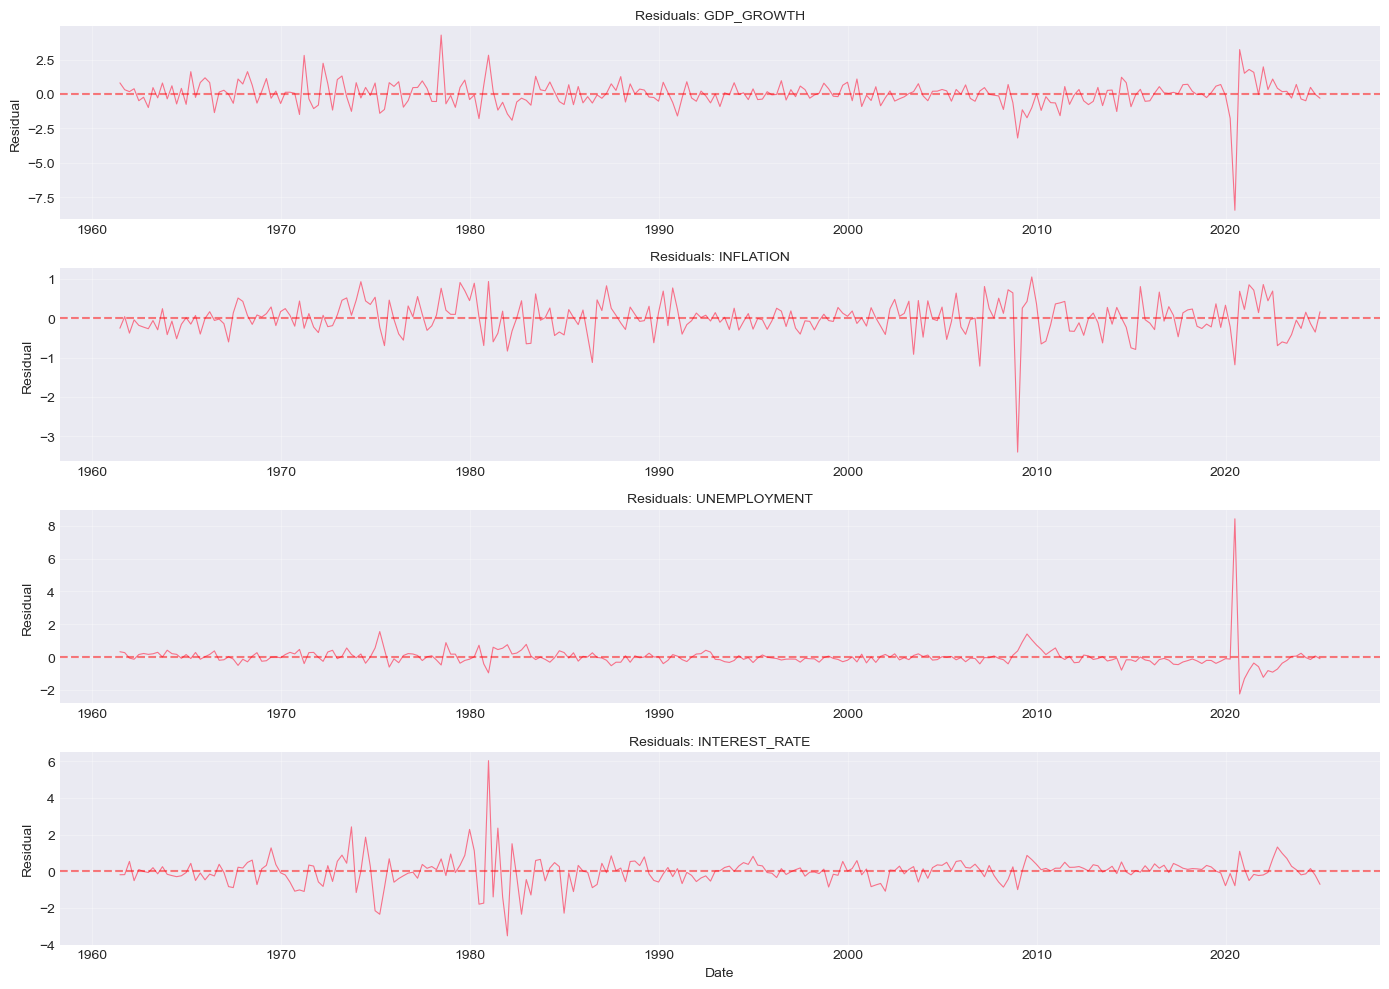

In [36]:
print("\n[Step 7] Model Diagnostics...")

# 1. Test for serial correlation in residuals
print("\n1. Serial Correlation Test (Durbin-Watson):")
dw_stats = var_model.test_whiteness(nlags=10, signif=0.05)
print(dw_stats.summary())

# 2. Test for normality of residuals
print("\n2. Normality Test (Jarque-Bera):")
jb_test = var_model.test_normality()
print(jb_test.summary())

# 3. Stability test
print("\n3. Stability Test (Eigenvalues):")
print("Checking if all eigenvalues are inside the unit circle...")
eigenvalues = var_model.roots
print(f"  Maximum eigenvalue magnitude: {np.max(np.abs(eigenvalues)):.4f}")
if np.max(np.abs(eigenvalues)) < 1:
    print("  ✓ Model is STABLE (all roots inside unit circle)")
else:
    print("  ✗ WARNING: Model may be UNSTABLE")

# Plot residuals
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
residuals = pd.DataFrame(var_model.resid, columns=df_stationary.columns, 
                         index=df_stationary.index[optimal_lag:])

for i, col in enumerate(residuals.columns):
    axes[i].plot(residuals.index, residuals[col], linewidth=0.8)
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[i].set_title(f'Residuals: {col}', fontsize=10)
    axes[i].set_ylabel('Residual')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [37]:
print("\n[Step 8] Granger Causality Analysis...")
print("Testing if variable X 'Granger-causes' variable Y")
print("(i.e., does X help predict Y?)\n")

variables = df_stationary.columns.tolist()
granger_results = pd.DataFrame(np.zeros((len(variables), len(variables))), 
                               columns=variables, index=variables)

for col in variables:
    for row in variables:
        if col != row:
            test_data = df_stationary[[row, col]]
            try:
                test_result = grangercausalitytests(test_data, maxlag=optimal_lag, verbose=False)
                # Get p-value for the optimal lag
                p_value = test_result[optimal_lag][0]['ssr_ftest'][1]
                granger_results.loc[row, col] = p_value
            except:
                granger_results.loc[row, col] = np.nan


[Step 8] Granger Causality Analysis...
Testing if variable X 'Granger-causes' variable Y
(i.e., does X help predict Y?)



In [39]:
test_result

{np.int64(1): ({'ssr_ftest': (np.float64(6.140547343319428),
    np.float64(0.013862351243379173),
    np.float64(254.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(6.213073493043673),
    np.float64(0.012681027400223742),
    np.int64(1)),
   'lrtest': (np.float64(6.139160654668785),
    np.float64(0.01322200597446713),
    np.int64(1)),
   'params_ftest': (np.float64(6.140547343319314),
    np.float64(0.013862351243380195),
    np.float64(254.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.5548029193416473),
    np.float64(0.030035095136345943),
    np.float64(251.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(7.251231452999694),
    np.float64(0.02663269383148304),
    np.int64(2)),
   'lrtest': (np.float64(7.150434408376441),
    np.float64(0.02800934136721214),
    np.int64(2)),
   'params_ftest': (np.float64(3.5548029193416317),
    np.float64(0.030035095136346696),
    np.float64(251.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],

In [38]:
print("Granger Causality Test Results (p-values):")
print("(Row → Column: Does Row Granger-cause Column?)")
print(granger_results.round(4))

print("\nSignificant Granger Causal Relationships (p < 0.05):")
for row in variables:
    for col in variables:
        if row != col:
            p_val = granger_results.loc[row, col]
            if not np.isnan(p_val) and p_val < 0.05:
                print(f"  • {row} → {col} (p-value: {p_val:.4f})")


Granger Causality Test Results (p-values):
(Row → Column: Does Row Granger-cause Column?)
               GDP_GROWTH  INFLATION  UNEMPLOYMENT  INTEREST_RATE
GDP_GROWTH         0.0000     0.2084        0.0000         0.0390
INFLATION          0.0681     0.0000        0.5233         0.0017
UNEMPLOYMENT       0.0231     0.0760        0.0000         0.0613
INTEREST_RATE      0.0110     0.1511        0.2760         0.0000

Significant Granger Causal Relationships (p < 0.05):
  • GDP_GROWTH → UNEMPLOYMENT (p-value: 0.0000)
  • GDP_GROWTH → INTEREST_RATE (p-value: 0.0390)
  • INFLATION → INTEREST_RATE (p-value: 0.0017)
  • UNEMPLOYMENT → GDP_GROWTH (p-value: 0.0231)
  • INTEREST_RATE → GDP_GROWTH (p-value: 0.0110)


In [ ]:
print("\n[Step 9] Generating Forecasts...")

# Forecast 8 quarters ahead
forecast_steps = 8
forecast = var_model.forecast(df_stationary.values[-optimal_lag:], steps=forecast_steps)
forecast_df = pd.DataFrame(forecast, columns=df_stationary.columns,
                          index=pd.date_range(start=df_stationary.index[-1], 
                                            periods=forecast_steps+1, freq='Q')[1:])

print("\nForecasted Values (Next 8 Quarters):")
print(forecast_df.round(2))

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
for i, col in enumerate(df_stationary.columns):
    # Historical data (last 40 quarters)
    axes[i].plot(df_stationary.index[-40:], df_stationary[col].iloc[-40:], 
                label='Historical', color='blue', linewidth=2)
    
    # Forecast
    axes[i].plot(forecast_df.index, forecast_df[col], 
                label='Forecast', color='red', linewidth=2, linestyle='--', marker='o')
    
    axes[i].set_title(f'{col} - Historical and Forecast', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(x=df_stationary.index[-1], color='gray', 
                   linestyle=':', alpha=0.7, label='Forecast Start')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [ ]:
print("\n[Step 10] Impulse Response Function Analysis...")

# Calculate IRF
irf = var_model.irf(10)  # 10 periods ahead

# Plot IRF
fig = irf.plot(orth=True, impulse=None, response=None, figsize=(14, 10))
plt.suptitle('Impulse Response Functions (Orthogonalized)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.show()

In [ ]:
print("\nKey IRF Analysis: Interest Rate Shock Effects")
print("(1 standard deviation shock to Interest Rate)")

irf_values = irf.orth_irfs
periods = np.arange(0, 11)

# Interest rate shock on GDP growth
interest_idx = list(df_stationary.columns).index('INTEREST_RATE')
gdp_idx = list(df_stationary.columns).index('GDP_GROWTH')
unemp_idx = list(df_stationary.columns).index('UNEMPLOYMENT')

gdp_response = irf_values[:, gdp_idx, interest_idx]
unemp_response = irf_values[:, unemp_idx, interest_idx]

print("\n  Period | GDP Growth Response | Unemployment Response")
print("  " + "-"*55)
for p in range(len(periods)):
    print(f"    {p:2d}   |     {gdp_response[p]:7.4f}       |       {unemp_response[p]:7.4f}")


In [ ]:
print("\n[Step 11] Forecast Error Variance Decomposition...")

fevd = var_model.fevd(10)
print("\nFEVD at Horizon 10 periods:")
print(fevd.summary())

# Plot FEVD
fig = fevd.plot(figsize=(14, 10))
plt.suptitle('Forecast Error Variance Decomposition', 
            fontsize=14, fontweight='bold', y=0.995)
plt.show()

In [ ]:
print("\n" + "="*70)
print("BUSINESS INSIGHTS AND INTERPRETATION")
print("="*70)

print("\n1. MODEL SUMMARY:")
print(f"   • VAR({optimal_lag}) model successfully estimated")
print(f"   • {len(df_stationary)} observations used")
print(f"   • Model is {'STABLE' if np.max(np.abs(eigenvalues)) < 1 else 'UNSTABLE'}")

print("\n2. VARIABLE RELATIONSHIPS:")
if granger_results.loc['INTEREST_RATE', 'GDP_GROWTH'] < 0.05:
    print("   • Interest rates SIGNIFICANTLY predict GDP growth")
else:
    print("   • Interest rates do NOT significantly predict GDP growth at 5% level")

if granger_results.loc['INTEREST_RATE', 'UNEMPLOYMENT'] < 0.05:
    print("   • Interest rates SIGNIFICANTLY predict unemployment")
else:
    print("   • Interest rates do NOT significantly predict unemployment at 5% level")

print("\n3. IMPULSE RESPONSE ANALYSIS:")
print("   Impact of 1% increase in interest rates:")
peak_gdp_effect = np.min(gdp_response)
peak_unemp_effect = np.max(unemp_response)
print(f"   • GDP Growth: Peak negative impact of {abs(peak_gdp_effect):.3f} percentage points")
print(f"   • Unemployment: Peak increase of {peak_unemp_effect:.3f} percentage points")

print("\n4. FORECASTING PERFORMANCE:")
print(f"   • 8-quarter ahead forecasts generated")
print(f"   • Next quarter GDP growth forecast: {forecast_df['GDP_GROWTH'].iloc[0]:.2f}%")
print(f"   • Next quarter unemployment forecast: {forecast_df['UNEMPLOYMENT'].iloc[0]:.2f}%")

print("\n5. POLICY IMPLICATIONS:")
print("   • Central bank interest rate decisions have measurable economic impacts")
print("   • Effects persist for multiple quarters (lag structure)")
print("   • VAR model useful for scenario analysis and policy simulation")

print("\n6. MODEL LIMITATIONS:")
print("   • Assumes linear relationships")
print("   • Historical patterns may not hold in structural breaks")
print("   • Forecast uncertainty increases with horizon")

print("\n" + "="*70)
print("CASE STUDY 1 COMPLETED SUCCESSFULLY!")
print("="*70)

print("\nGenerated Files:")
print("  1. case1_timeseries_plots.png - Time series visualization")
print("  2. case1_correlation.png - Correlation matrix")
print("  3. case1_scatter_matrix.png - Pairwise relationships")
print("  4. case1_residuals.png - Model residual analysis")
print("  5. case1_forecasts.png - Historical data and forecasts")
print("  6. case1_irf.png - Impulse response functions")
print("  7. case1_fevd.png - Forecast error variance decomposition")

In [ ]:
results_summary = {
    'optimal_lag': optimal_lag,
    'sample_size': len(df_stationary),
    'model_stable': np.max(np.abs(eigenvalues)) < 1,
    'forecast_8q_gdp': forecast_df['GDP_GROWTH'].iloc[0],
    'forecast_8q_unemployment': forecast_df['UNEMPLOYMENT'].iloc[0],
    'granger_causality': granger_results.to_dict()
}

print("\n\n" + "="*70)
print("Ready for Discussion and Q&A!")
print("="*70)

In [ ]:
results_summary